# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv(r"C:\Users\User\Desktop\DATA LOVES ACADEMY\DATA\yulu_rental.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [4]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19,2012-12
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20,2012-12
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21,2012-12


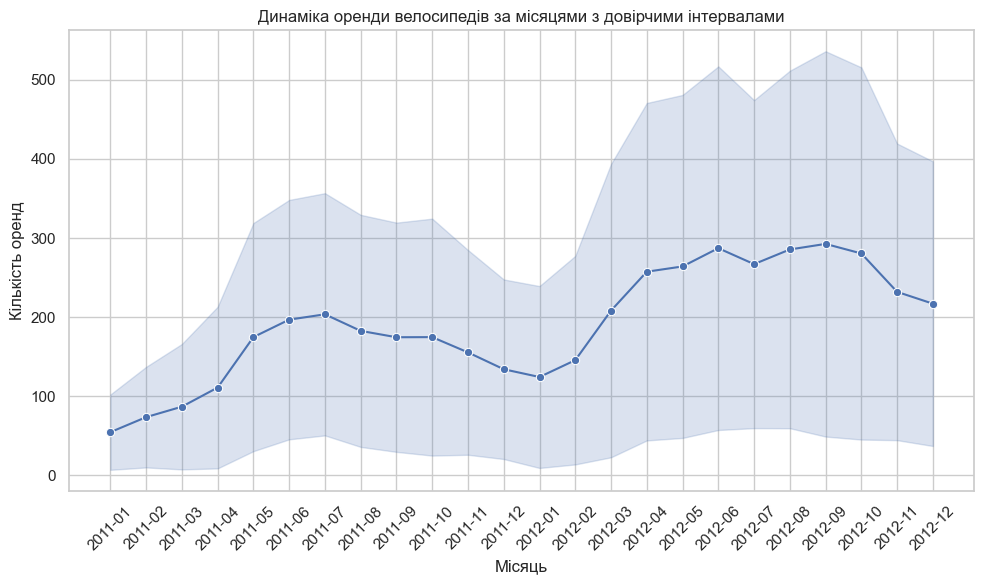

In [7]:
plt.figure(figsize=(10,6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout()

Найбільша невизначеність спостерігається у другій половині 2012 року, особливо в серпні–вересні 2012, оскільки саме в ці місяці довірчий інтервал є найширшим.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

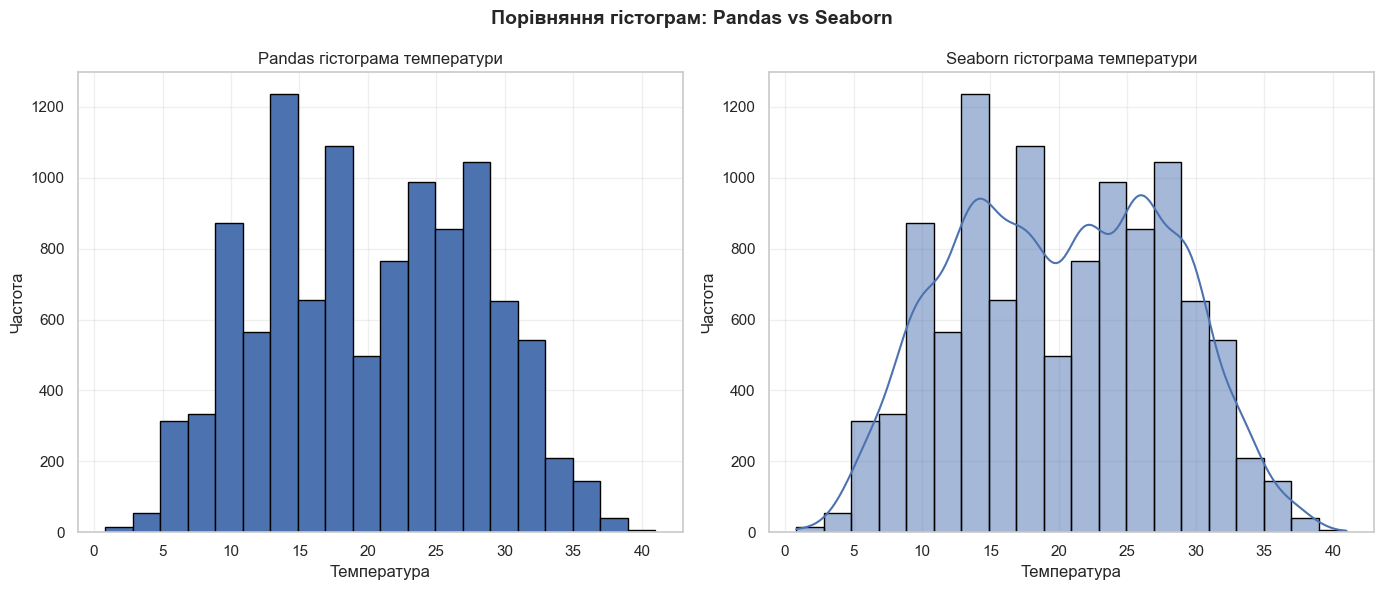

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (14, 6))

# Pandas
df['temp'].plot(
    kind='hist',
    bins=20,
    ax=ax[0],
    edgecolor='black'
)

ax[0].set_title('Pandas гістограма температури')
ax[0].set_xlabel('Температура')
ax[0].set_ylabel('Частота')
ax[0].grid(alpha=0.3)

# Seaborn

sns.histplot(
    data=df,
    x='temp',
    bins = 20,
    kde = True,
    ax = ax[1],
    edgecolor = 'black'
)

ax[1].set_title('Seaborn гістограма температури')
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Частота')
ax[1].grid(alpha=0.3)

fig.suptitle('Порівняння гістограм: Pandas vs Seaborn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



1. Яка візуальна різниця між Pandas та Seaborn гістограмами?

    Pandas гістограма є більш простою та базовою, оскільки показує лише стовпчики частот. Seaborn гістограма виглядає більш інформативно, бо додатково містить плавну лінію розподілу

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

    Це згладжена крива, яка показує, де дані зустрічаються частіше, а де рідше

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

C:\Users\User\AppData\Local\Temp\ipykernel_10480\2710413761.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(weather_labels)


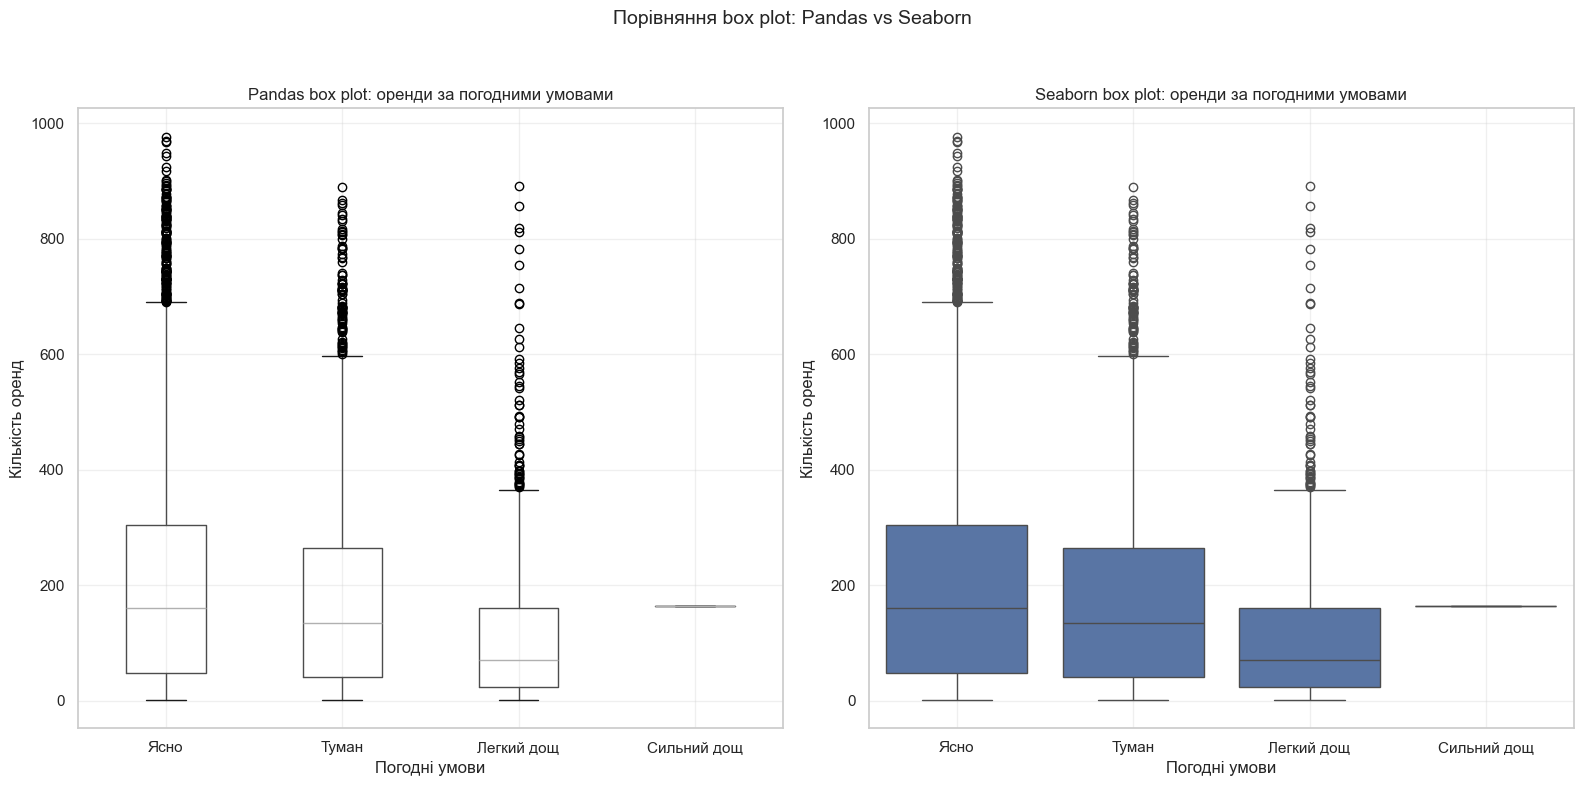

In [22]:

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Pandas
df.boxplot(
    column='count',
    by='weather',
    ax=ax[0],
    grid=False
)

ax[0].set_title('Pandas box plot: оренди за погодними умовами')
ax[0].set_xlabel('Погодні умови')
ax[0].set_ylabel('Кількість оренд')
ax[0].set_xticklabels(weather_labels)
ax[0].grid(alpha=0.3)

# 2. Box plot через Seaborn
sns.boxplot(
    data=df,
    x='weather',
    y='count',
    ax=ax[1]
)

ax[1].set_title('Seaborn box plot: оренди за погодними умовами')
ax[1].set_xlabel('Погодні умови')
ax[1].set_ylabel('Кількість оренд')
ax[1].set_xticklabels(weather_labels)
ax[1].grid(alpha=0.3)


fig.suptitle('Порівняння box plot: Pandas vs Seaborn', fontsize=14)
fig.tight_layout(rect = [0, 0, 1, 0.95])
plt.show()

Обидва графіки показують однакові статистичні характеристики розподілу, але Seaborn зручніший для створення візуалізацій.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [23]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
corr_matrix

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day,week,weekday_num,year,month,hour
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439,0.001729,0.939284,-0.010553,-0.004797,0.971524,-0.006546
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393,-0.015877,0.000976,-0.191832,0.012021,0.001731,-0.000354
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594,0.009829,-0.022593,-0.704267,-0.002482,-0.003394,0.002780
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655,-0.007890,0.019762,-0.047692,-0.012548,0.012144,-0.022740
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454,0.015551,0.240794,-0.038466,0.061226,0.257589,0.145430
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784,0.011866,0.248653,-0.040235,0.058540,0.264173,0.140343
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371,-0.011335,0.216435,-0.026507,-0.078606,0.204537,-0.278011
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369,0.036157,-0.145962,-0.024804,-0.015221,-0.150192,0.146631
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414,0.014109,0.079906,0.246959,0.145241,0.092722,0.302045
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948,0.019111,0.156480,-0.084427,0.264265,0.169451,0.380540


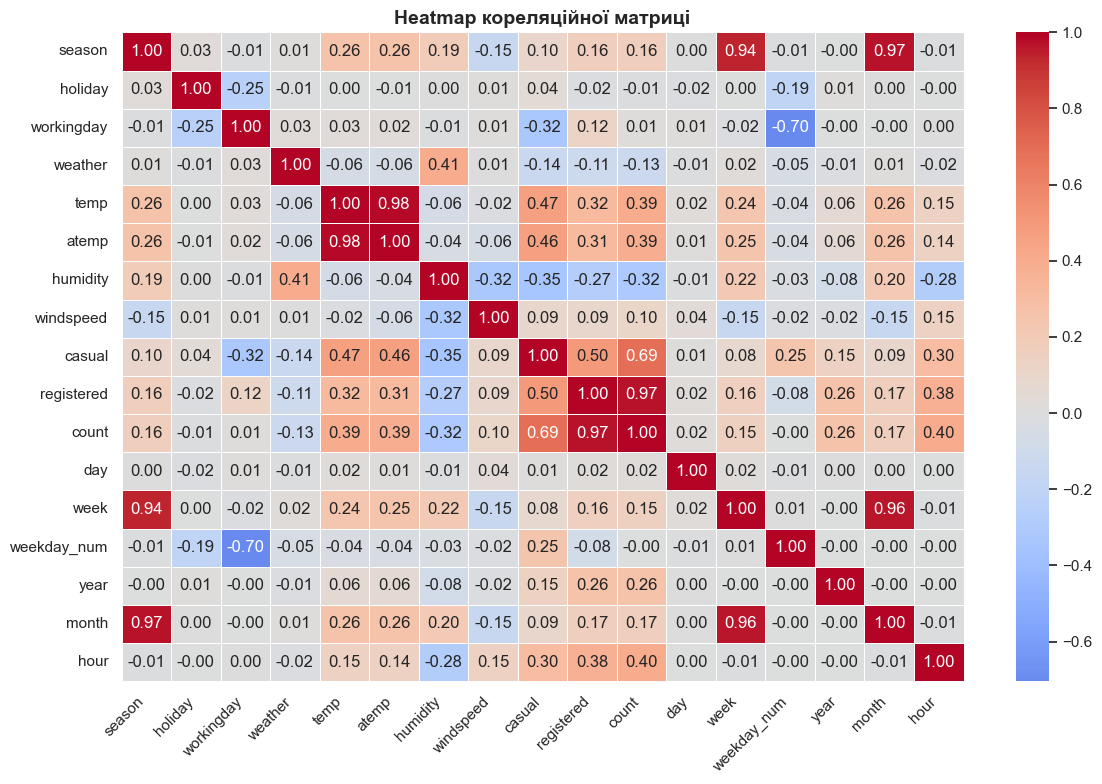

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # показати числа в клітинках
    fmt='.2f',         # 2 знаки після коми
    cmap='coolwarm',   # синьо-червона палітра
    center=0,          # 0 по центру кольорової шкали
    linewidths=0.5
)

plt.title('Heatmap кореляційної матриці', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

    Найсильніша позитивна кореляція з count у таких змінних: registered = 0,97, casual = 0,69. Трохи менш позитивний зв’язок: hour = 0,40 та temp = 0,39


2. Яка кореляція між temp та atemp? Чому?

    Це показник фактичної температури та як "відчувається" ця температура. Мають дуже сильну позитивну кореляцію, тому що при зростанні/знижені реальної температури, відчутна температура теж буде змінюватись в тому ж напрямку.

3. Які змінні мають негативну кореляцію?

    Негативну кореляцію з count мають humidity (-0,32) і weather (-0,13), тобто при більшій вологості та гіршій погоді кількість оренд зменшується.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


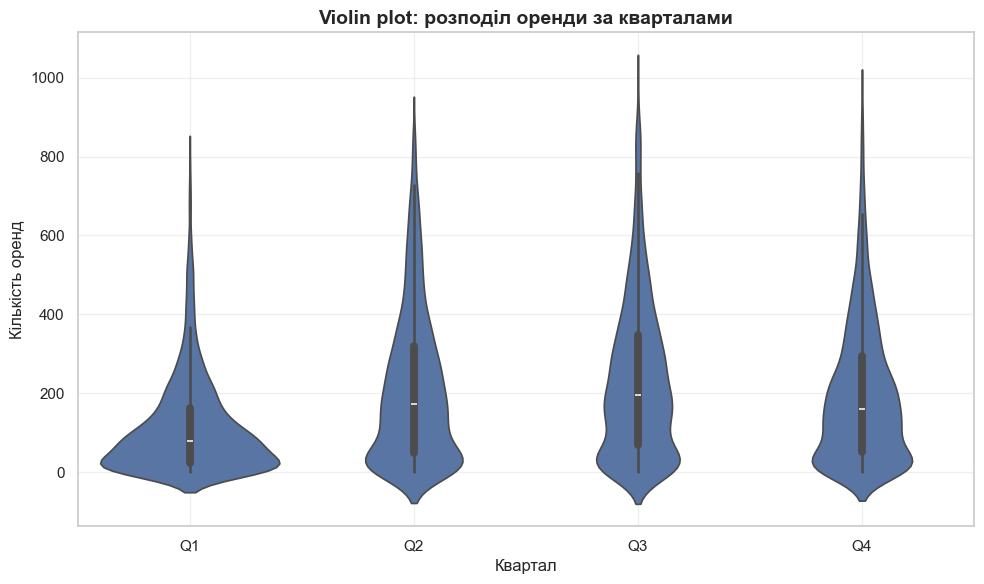

In [27]:
quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='season',
    y='count',
    inner='box'
)

ax.set_title('Violin plot: розподіл оренди за кварталами', fontsize=14, fontweight='bold')
ax.set_xlabel('Квартал')
ax.set_ylabel('Кількість оренд')
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(quarter_labels)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Що показує "товщина" violin plot?

    Товщина показує, де значення зустрічаються частіше.

2. В якому кварталі найбільша варіабельність оренди?

    В третьому кварталі

3. Яка перевага violin plot над звичайним box plot?

    box plot показує коротку статистичну вижимку, а violin plot ще й показує, як саме розподілені дані всередині.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

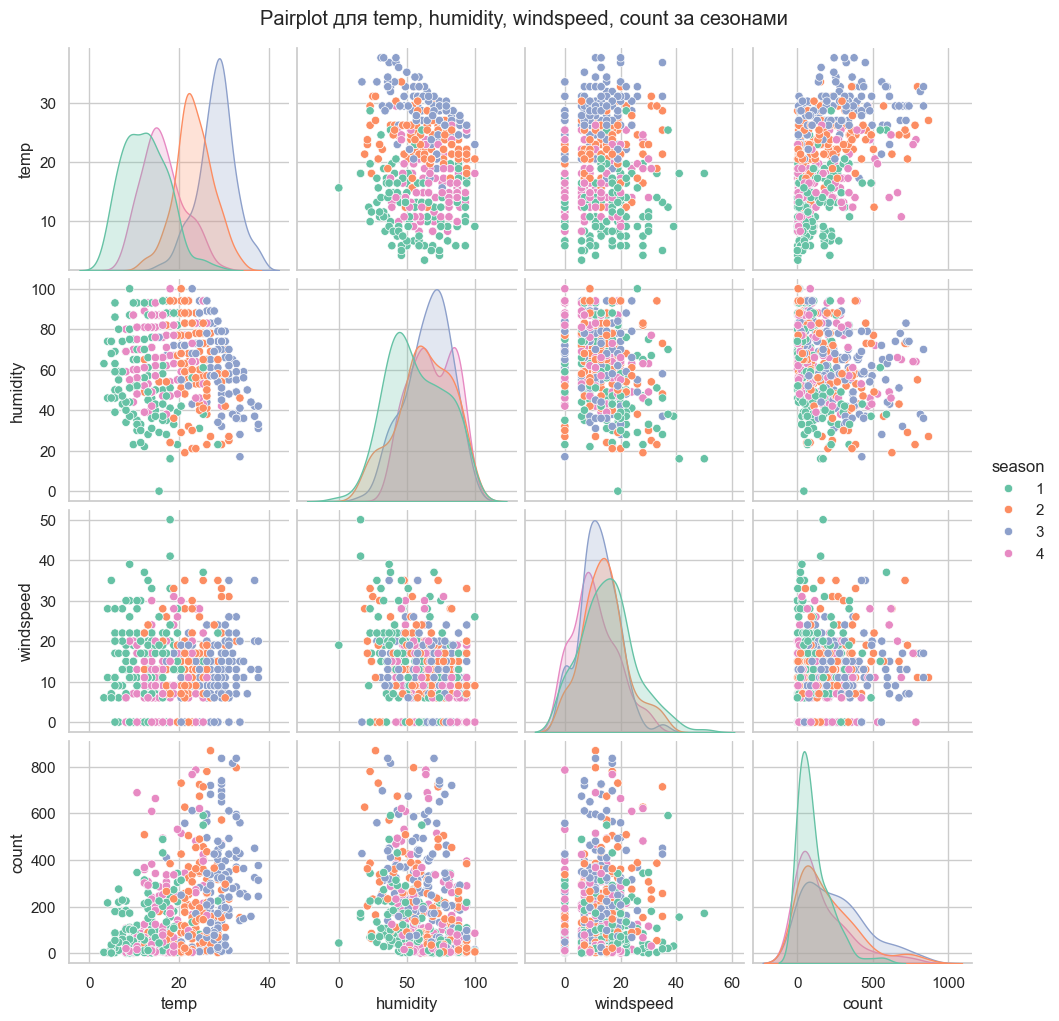

In [33]:
pairplot_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']].sample(frac=0.05)

g = sns.pairplot(
    data=pairplot_df,
    vars=['temp', 'humidity', 'windspeed', 'count'],
    hue='season',
    palette = 'Set2'
)

g.fig.suptitle('Pairplot для temp, humidity, windspeed, count за сезонами', y=1.02)
plt.show()

1. Між якими змінними спостерігається найсильніший лінійний зв'язок?

    Між температурою та кількістю оренд велосипедів

2. Яка характеристика найбільше відрізняється між кварталами?

    Температура, оренда.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

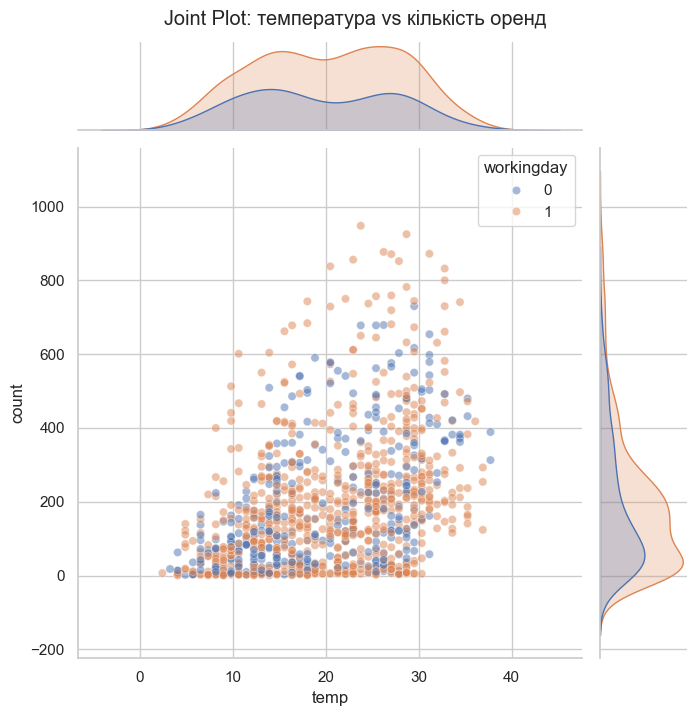

In [34]:
sample_df = df[['temp', 'count', 'workingday']].sample(frac=0.1, random_state=42)

g = sns.jointplot(
    data=sample_df,
    x='temp',
    y='count',
    hue='workingday',
    kind='scatter',
    height=7,
    alpha=0.5
)

g.figure.suptitle('Joint Plot: температура vs кількість оренд', y=1.02)
plt.show()

1. Що показують графіки по краях?

    Графіки по краях показують окремі розподіли кожної змінної

2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

    Температура впливає на попит і в робочі, і в неробочі дні, але в робочі дні користувачі активніші